In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# LR-Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier


# Model Evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

from sklearn.metrics import accuracy_score,classification_report

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Save Model
import joblib

In [2]:
df=pd.read_excel('Online_Retail.xlsx')
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [5]:
df.shape

(541909, 8)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df=df.drop_duplicates()

In [10]:
df=df.dropna(subset=['CustomerID'])

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.7+ MB


In [12]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [13]:
df.shape

(401604, 8)

In [14]:
df['Description'].nunique()

3896

In [15]:
df['Quantity'].describe()

count    401604.000000
mean         12.183273
std         250.283037
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [16]:
df=df[df['Quantity']>0]
df['Quantity'].describe()

count    392732.000000
mean         13.153718
std         181.588420
min           1.000000
25%           2.000000
50%           6.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

In [17]:
df['UnitPrice'].describe()

count    392732.000000
mean          3.125596
std          22.240725
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64

In [18]:
df=df[df['UnitPrice']>=1]
df['UnitPrice'].describe()

count    301022.000000
mean          3.894946
std          25.353534
min           1.000000
25%           1.650000
50%           2.460000
75%           4.250000
max        8142.750000
Name: UnitPrice, dtype: float64

In [19]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,301022.000000,301022,301022.000000,301022.000000
mean,10.360329,2011-07-08 10:30:03.864435,3.894946,15290.651726
min,1.000000,2010-12-01 08:26:00,1.000000,12346.000000
25%,2.000000,2011-04-03 14:48:15,1.650000,13969.000000
50%,4.000000,2011-07-27 14:21:00,2.460000,15150.000000
75%,10.000000,2011-10-19 12:54:00,4.250000,16794.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,202.740530,NaN,25.353534,1711.923977


In [20]:
df['Revenue']=df['Quantity']*df['UnitPrice']

In [21]:
df.head(7)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50


In [22]:
df['InvoiceNo'].nunique()

18185

In [23]:
df['Revenue'].describe()

count    301022.000000
mean         26.053799
std         354.787818
min           1.000000
25%           5.900000
50%          15.000000
75%          20.280000
max      168469.600000
Name: Revenue, dtype: float64

In [24]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month_name()
df['Day'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour
df['Minute'] = df['InvoiceDate'].dt.minute

In [25]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day,Hour,Minute
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,December,Wednesday,8,26
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,Wednesday,8,26
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,December,Wednesday,8,26
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,Wednesday,8,26
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,December,Wednesday,8,26


In [26]:
df.info()

<class 'pandas.DataFrame'>
Index: 301022 entries, 0 to 541908
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    301022 non-null  object        
 1   StockCode    301022 non-null  object        
 2   Description  301022 non-null  object        
 3   Quantity     301022 non-null  int64         
 4   InvoiceDate  301022 non-null  datetime64[us]
 5   UnitPrice    301022 non-null  float64       
 6   CustomerID   301022 non-null  float64       
 7   Country      301022 non-null  str           
 8   Revenue      301022 non-null  float64       
 9   Year         301022 non-null  int32         
 10  Month        301022 non-null  str           
 11  Day          301022 non-null  str           
 12  Hour         301022 non-null  int32         
 13  Minute       301022 non-null  int32         
dtypes: datetime64[us](1), float64(3), int32(3), int64(1), object(3), str(3)
memory usage: 38.7+ MB


In [27]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue,Year,Hour,Minute
count,301022.000000,301022,301022.000000,301022.000000,301022.000000,301022.000000,301022.000000,301022.000000
mean,10.360329,2011-07-08 10:30:03.864435,3.894946,15290.651726,26.053799,2010.930885,12.716559,30.463049
min,1.000000,2010-12-01 08:26:00,1.000000,12346.000000,1.000000,2010.000000,6.000000,0.000000
25%,2.000000,2011-04-03 14:48:15,1.650000,13969.000000,5.900000,2011.000000,11.000000,16.000000
50%,4.000000,2011-07-27 14:21:00,2.460000,15150.000000,15.000000,2011.000000,13.000000,31.000000
75%,10.000000,2011-10-19 12:54:00,4.250000,16794.000000,20.280000,2011.000000,14.000000,45.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,2011.000000,20.000000,59.000000
std,202.740530,NaN,25.353534,1711.923977,354.787818,0.253649,2.280455,17.047776


In [28]:
df['Year'].nunique()

2

In [29]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
Year           0
Month          0
Day            0
Hour           0
Minute         0
dtype: int64

In [30]:
print("Total_Revenue: ",df['Revenue'].sum())

Total_Revenue:  7842766.74


In [31]:
print("Total_order: ",df['InvoiceNo'].nunique())

Total_order:  18185


In [32]:
print("Total_customer: ",df['CustomerID'].nunique())

Total_customer:  4304


In [33]:
print("Total_product: ",df['Description'].nunique())

Total_product:  3230


In [34]:
print("Total Countries: ",df['Country'].nunique())

Total Countries:  37


### Yearly Revenue Analysis

In [35]:
yearly = df.groupby('Year')['Revenue'].sum()

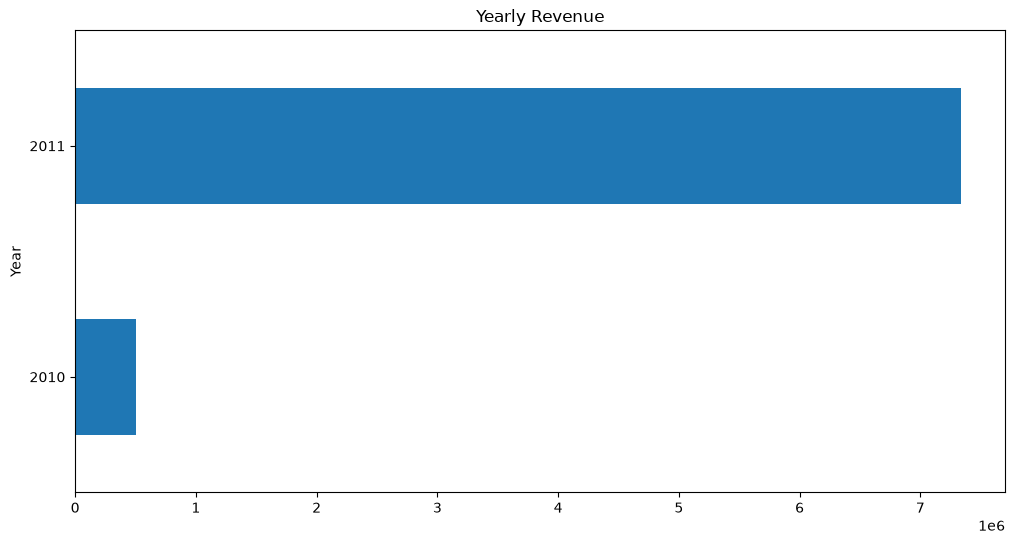

In [36]:
yearly.plot(kind='barh', figsize=(12,6))
plt.title("Yearly Revenue")
plt.show()

### Monthly Revenue Analysis

In [37]:
monthly = df.groupby('Month')['Revenue'].sum()

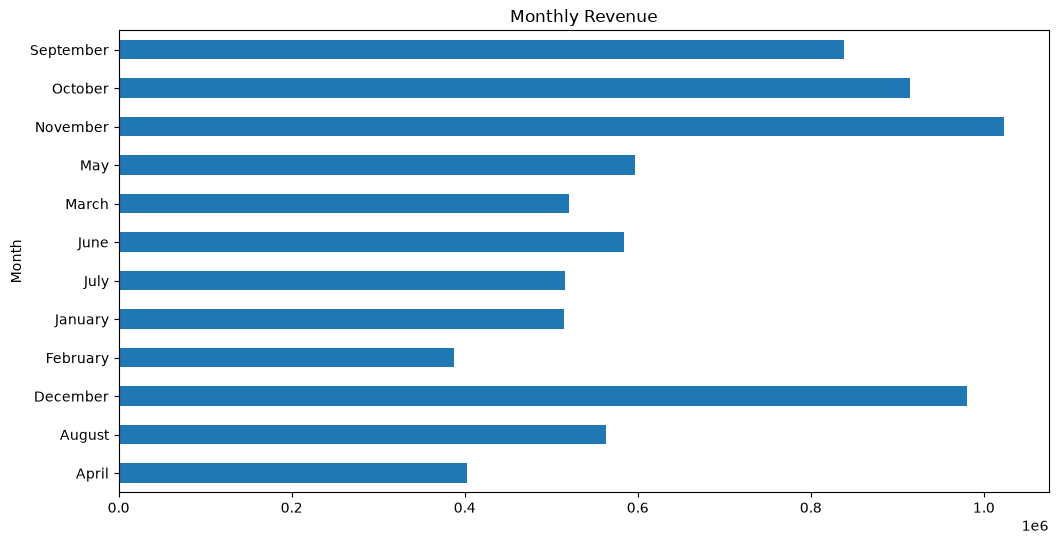

In [38]:
monthly.plot(kind='barh', figsize=(12,6))
plt.title("Monthly Revenue")
plt.show()

### Country Wise-Revenue

In [39]:
country = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

Text(0.5, 1.0, 'Top 10 Countries by Revenue')

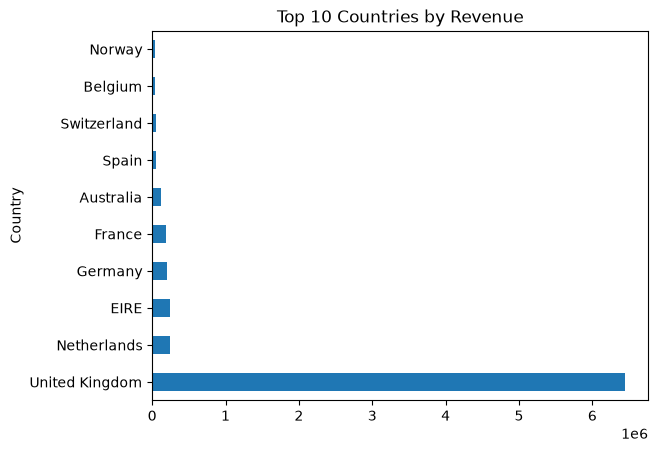

In [40]:
country.head(10).plot(kind='barh')
plt.title("Top 10 Countries by Revenue")

### Top Selling Product

In [41]:
products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False)

Text(0.5, 1.0, 'Top Selling Products')

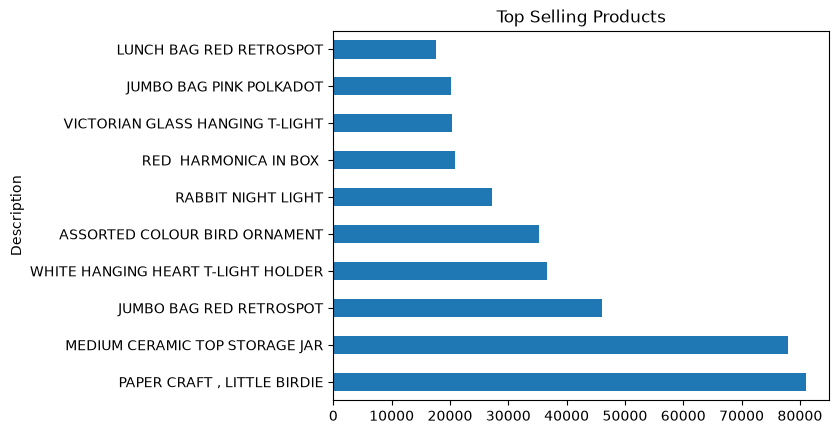

In [42]:
products.head(10).plot(kind='barh')
plt.title("Top Selling Products")

### Top7 Revenue Generated Products

In [43]:
revenue_product = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False)

Text(0.5, 1.0, 'Top7 Revenue Generated Products')

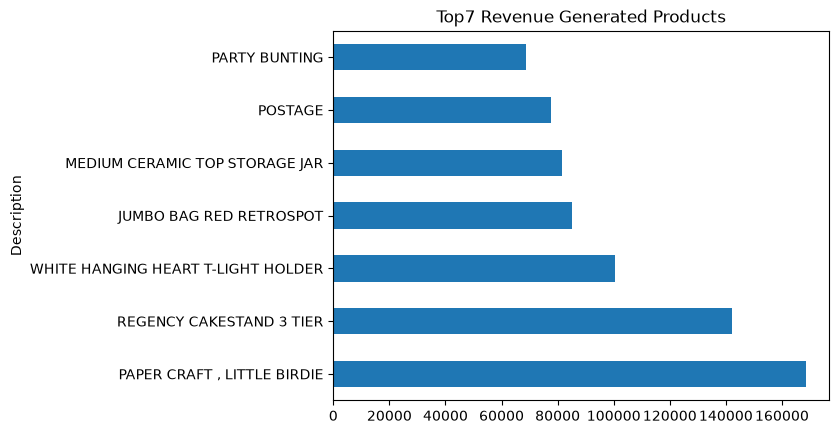

In [44]:
revenue_product.head(7).plot(kind='barh')
plt.title("Top7 Revenue Generated Products")

### Sales By Year

Text(0.5, 1.0, 'Revenue by Year')

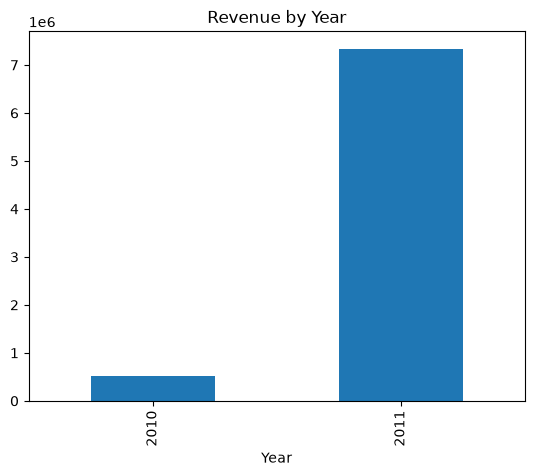

In [45]:
year_sales = df.groupby('Year')['Revenue'].sum()

year_sales.plot(kind='bar')
plt.title("Revenue by Year")

### Sales By Hours

Text(0.5, 1.0, 'Revenue by Hour')

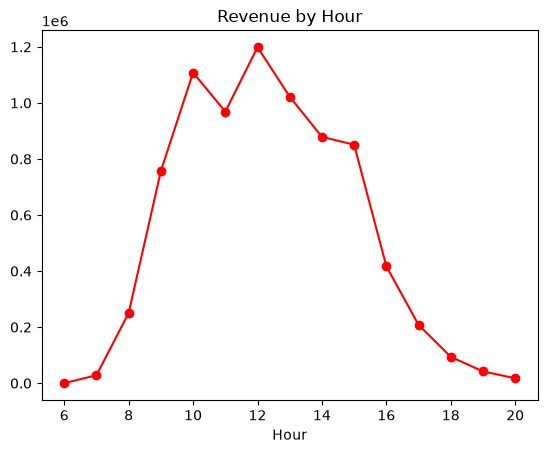

In [46]:
hour_sales = df.groupby('Hour')['Revenue'].sum()

hour_sales.plot(marker='o',color='red')
plt.title("Revenue by Hour")

### Sales By Day

Text(0.5, 1.0, 'Revenue by Day')

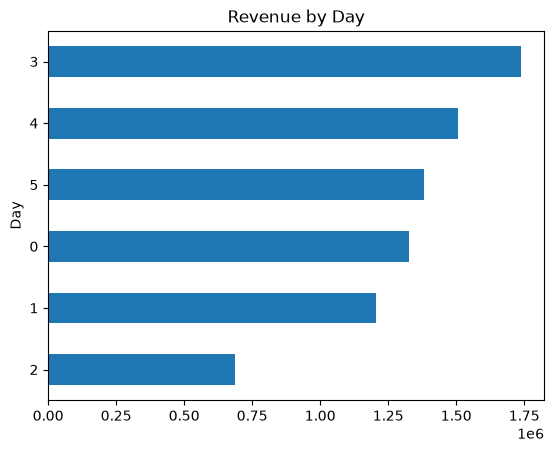

In [101]:
day_sales = df.groupby('Day')['Revenue'].sum().sort_values(ascending=True)

day_sales.plot(kind='barh')
plt.title("Revenue by Day")

### Customer Analysis

#### Top Customers

Text(0.5, 1.0, 'Top Cuustomers')

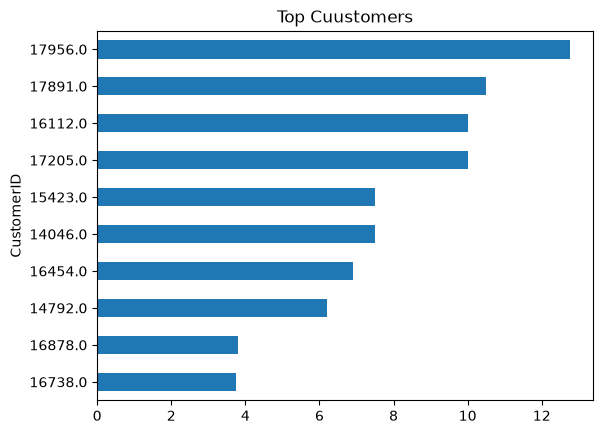

In [48]:
customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=True)
customers.head(10).plot(kind='barh')
plt.title("Top Cuustomers")

#### Customer Purchase Frequency

Text(0.5, 1.0, 'Customer Purchase Frequency')

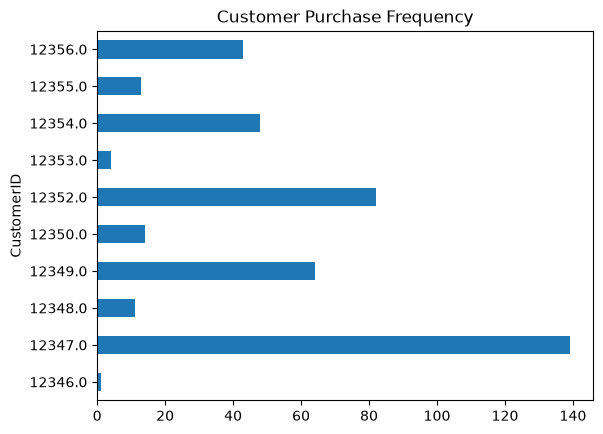

In [49]:
purchase = df.groupby('CustomerID')['InvoiceNo'].count()
purchase.head(10).plot(kind='barh')
plt.title("Customer Purchase Frequency")

### Correlation 

<Axes: >

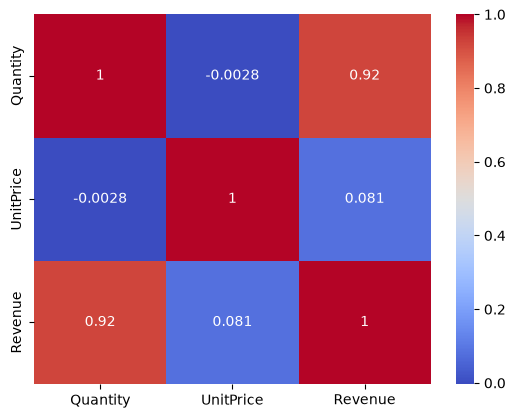

In [50]:
sns.heatmap(df[['Quantity','UnitPrice','Revenue']].corr(),
            annot=True,
            cmap='coolwarm')

### KMeas Modeling

In [51]:
customer_data = df.groupby('CustomerID').agg({
    'Revenue':'sum',
    'Quantity':'sum',
    'InvoiceNo':'nunique'
}).reset_index()

customer_data.rename(columns={
    'InvoiceNo':'TotalOrders'
}, inplace=True)

customer_data.head()

,CustomerID,Revenue,Quantity,TotalOrders
0,12346.0,77183.60,74215,1
1,12347.0,3764.48,1578,7
2,12348.0,1114.00,593,4
3,12349.0,1668.75,497,1
4,12350.0,295.30,151,1


#### Standard Scaler

In [52]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(customer_data)

#### Elbo Method 

In [53]:
wcss=[]
for i in range(1,11):
    kmodel = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmodel.fit(X_scaled)
    wcss.append(kmodel.inertia_)
print(wcss)

[17216.0, 10759.723161173377, 7554.88228368043, 5559.4747894537995, 4481.982739403718, 3748.540419094368, 3190.4230536579867, 2761.1283818825223, 2563.3264130407865, 2264.863954294283]


Text(0.5, 1.0, 'Elbow Method')

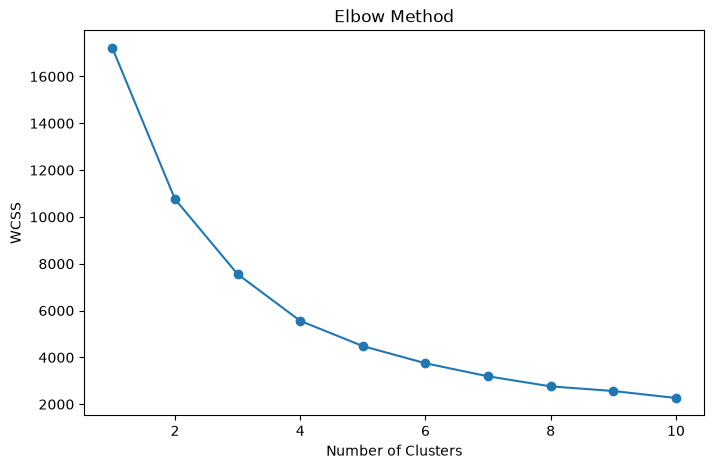

In [54]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

In [55]:
#silhouette_score
#for k in range(1,11):
 #   kmodel1=KMeans(
 #       n_clusters=k,
 #       random_state=42,
 #       n_init=10
 #   )
 #   labels=kmodel1.fit_predict(X_scaled)
#    scores=silhouette_score(X_scaled,labels)
#    print(f"K is {k}, and silhouette-score is {round(scores,2)} ")

In [56]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_data['Cluster'] = kmeans.fit_predict(X_scaled)

In [57]:
customer_data.groupby('Cluster').mean()

,CustomerID,Revenue,Quantity,TotalOrders
Cluster,,,,
0,13814.204717,1347.009892,509.196698,3.708962
1,15059.000000,159924.255000,67283.625000,56.750000
2,15260.982143,26400.523929,11149.839286,40.964286
3,16787.420755,1051.548297,413.457547,3.572642


In [58]:
customer_data.head()

,CustomerID,Revenue,Quantity,TotalOrders,Cluster
0,12346.0,77183.60,74215,1,1
1,12347.0,3764.48,1578,7,0
2,12348.0,1114.00,593,4,0
3,12349.0,1668.75,497,1,0
4,12350.0,295.30,151,1,0


In [59]:
customer_data['Cluster'].unique()

array([1, 0, 2, 3], dtype=int32)

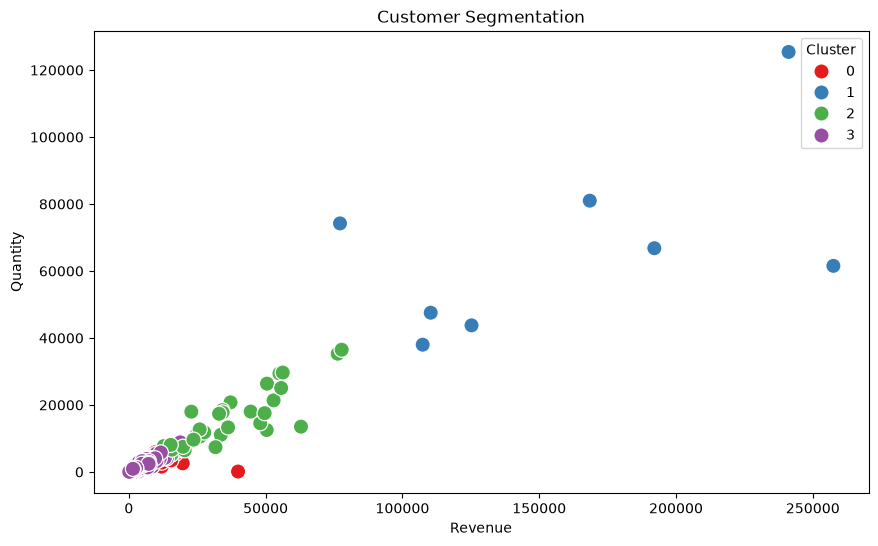

In [60]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_data,
    x='Revenue',
    y='Quantity',
    hue='Cluster',
    palette='Set1',
    s=120
)

plt.title("Customer Segmentation")
plt.show()

In [61]:
customer_data['Cluster'].value_counts()

Cluster
0    2120
3    2120
2      56
1       8
Name: count, dtype: int64

### RandomForest Model

#### Encode Country

In [68]:
encoder_mon = LabelEncoder()
encoder_day = LabelEncoder()
encoder_con = LabelEncoder()
encoder = LabelEncoder()

df['Month'] = encoder.fit_transform(df['Month'])
df['Day'] = encoder.fit_transform(df['Day'])
df['Country'] = encoder.fit_transform(df['Country'])

#print("Month Mappings:")
#for index, label in enumerate(encoder_mon.classes_):
    #print(f"{label} -> {index}")
    #print("Month Mappings:")
#for index, label in enumerate(encoder_day.classes_):
    #print(f"{label} -> {index}")
   # print("Month Mappings:")
#for index, label in enumerate(encoder_con.classes_):
   # print(f"{label} -> {index}")

In [69]:
# Features 

features = [
    'Quantity',
    'UnitPrice',
    'Country',
    'Month',
    'Day',
    'Hour'
]

X = df[features]

y = df['Revenue']

In [70]:
print(X.head())
print(X.dtypes)

   Quantity  UnitPrice  Country  Month  Day  Hour
0         6       2.55       35      2    5     8
1         6       3.39       35      2    5     8
2         8       2.75       35      2    5     8
3         6       3.39       35      2    5     8
4         6       3.39       35      2    5     8
Quantity       int64
UnitPrice    float64
Country        int64
Month          int64
Day            int64
Hour           int32
dtype: object


#### Train and Test

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [72]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(

    n_estimators=200,

    random_state=42
)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

#### Prediction

In [73]:
prediction = rf.predict(X_test)
prediction

array([15.     , 30.6    , 76.65895, ..., 12.7266 , 12.6    , 19.9    ],
      shape=(60205,))

#### Evaluation

In [74]:
print("MAE :",mean_absolute_error(y_test,prediction))

print("MSE :",mean_squared_error(y_test,prediction))

print("RMSE :",np.sqrt(mean_squared_error(y_test,prediction)))

print("R2 Score :",r2_score(y_test,prediction))

MAE : 0.7898214990450507
MSE : 23137.239933400193
RMSE : 152.10930258666033
R2 Score : 0.23664377470473408


#### Actual VS Predicted

In [75]:
result = pd.DataFrame({

    "Actual":y_test,

    "Predicted":prediction

})

result.head(10)

,Actual,Predicted
384894,15.00,15.00000
86777,30.60,30.60000
469826,75.46,76.65895
109905,59.40,59.40000
75578,10.95,10.95000
330886,15.00,15.00000
14464,35.40,35.40000
467625,20.80,20.80000
201102,1.65,1.65000
101954,19.50,19.50000


Text(0.5, 1.0, 'Actual vs Predicted')

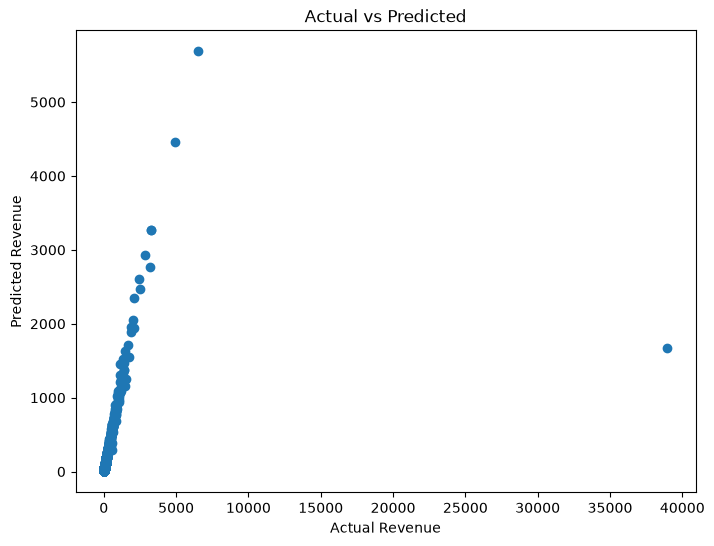

In [76]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,prediction)

plt.xlabel("Actual Revenue")

plt.ylabel("Predicted Revenue")

plt.title("Actual vs Predicted")

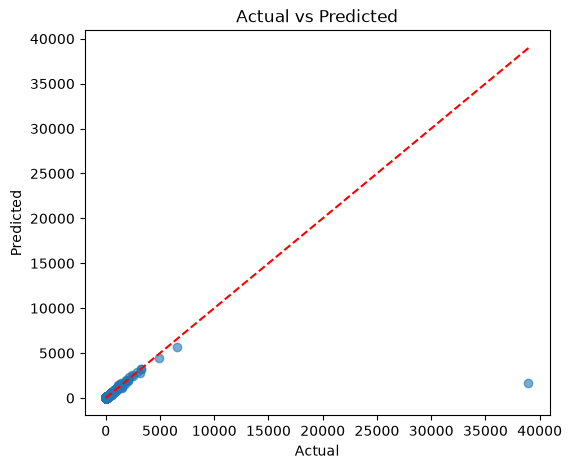

In [100]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, prediction, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [77]:
importance = pd.DataFrame({

    'Feature':features,

    'Importance':rf.feature_importances_

})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
0   Quantity    0.892214
1  UnitPrice    0.089784
5       Hour    0.008116
4        Day    0.005040
3      Month    0.004615
2    Country    0.000231


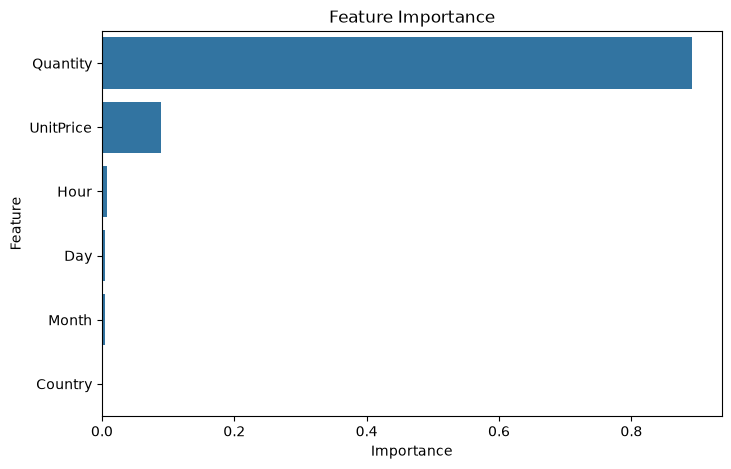

In [78]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=importance,

    x='Importance',

    y='Feature'

)

plt.title("Feature Importance")

plt.show()

### RFM

In [79]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta('1 day')
reference_date

Timestamp('2011-12-10 12:50:00')

In [80]:
# Calculate Recency, Frequency, and Monetary value
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  
    'InvoiceNo': 'nunique',                                    
    'Revenue': 'sum'                                           
}).reset_index()

In [81]:
rfm

,CustomerID,InvoiceDate,InvoiceNo,Revenue
0,12346.0,326,1,77183.60
1,12347.0,2,7,3764.48
2,12348.0,75,4,1114.00
3,12349.0,19,1,1668.75
4,12350.0,310,1,295.30
...,...,...,...,...
4299,18280.0,278,1,180.60
4300,18281.0,181,1,65.70
4301,18282.0,8,2,152.45
4302,18283.0,4,16,1714.85


In [82]:
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'Revenue': 'Monetary'
}, inplace=True)

In [83]:
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,3764.48
2,12348.0,75,4,1114.00
3,12349.0,19,1,1668.75
4,12350.0,310,1,295.30
...,...,...,...,...
4299,18280.0,278,1,180.60
4300,18281.0,181,1,65.70
4301,18282.0,8,2,152.45
4302,18283.0,4,16,1714.85


Text(0.5, 1.0, 'Monetary Ditribution')

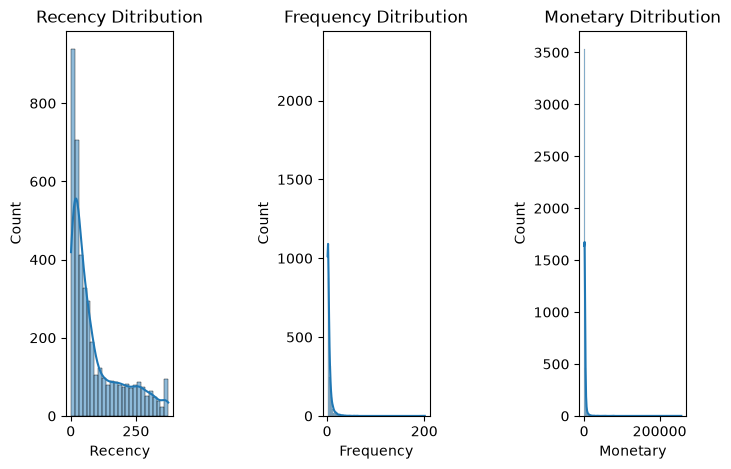

In [84]:
plt.figure(figsize=(8,5))
plt.subplot(1,5,1)
sns.histplot(rfm['Recency'], kde=True)
plt.title('Recency Ditribution')

plt.subplot(1,5,3)
sns.histplot(rfm['Frequency'], kde=True)
plt.title('Frequency Ditribution')

plt.subplot(1,5,5)
sns.histplot(rfm['Monetary'], kde=True)
plt.title('Monetary Ditribution')

In [85]:
# select features
features = rfm[['Recency','Frequency','Monetary']]
features

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,3764.48
2,75,4,1114.00
3,19,1,1668.75
4,310,1,295.30
...,...,...,...
4299,278,1,180.60
4300,181,1,65.70
4301,8,2,152.45
4302,4,16,1714.85


In [86]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features)

In [87]:
wcss = []
for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state = 42,
        n_init = 10
    )
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)
print(wcss)

[9075.913197145996, 5479.363267678962, 4070.856316529631, 3031.522681665528, 2447.3192087392194, 1983.112041769928, 1692.729874384765, 1405.3763427470383, 1238.6214963527368]


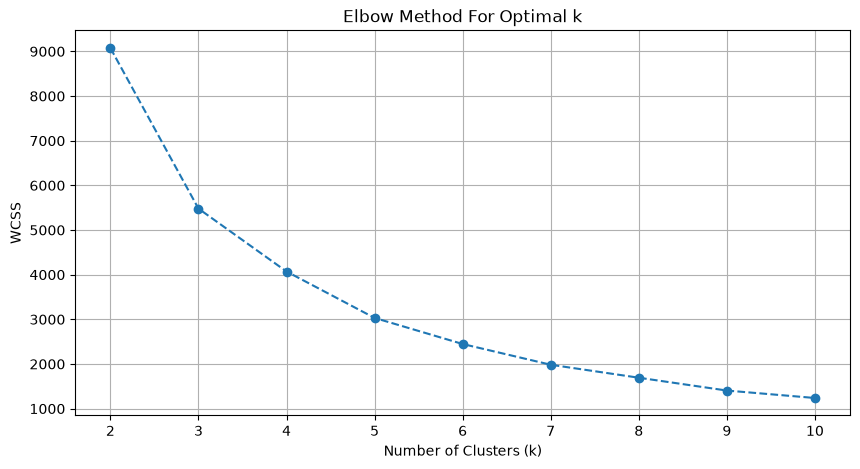

In [88]:
# Plot Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(range(2,11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [89]:
#silhouette_score
for k in range(2,11):
    km_model1=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels=km_model1.fit_predict(rfm_scaled)
    score=silhouette_score(rfm_scaled,labels)
    print(f"K is {k}, and silhouette-score is {round(score,2)} ")

K is 2, and silhouette-score is 0.89 
K is 3, and silhouette-score is 0.58 
K is 4, and silhouette-score is 0.62 
K is 5, and silhouette-score is 0.62 
K is 6, and silhouette-score is 0.59 
K is 7, and silhouette-score is 0.52 
K is 8, and silhouette-score is 0.48 
K is 9, and silhouette-score is 0.48 
K is 10, and silhouette-score is 0.42 


In [90]:
kmeans = KMeans(
    n_clusters = 4,
    random_state = 42,
    n_init = 10
)

In [91]:
rfm['kmeans cluster'] = kmeans.fit_predict(rfm_scaled)

In [92]:
rfm

,CustomerID,Recency,Frequency,Monetary,kmeans cluster
0,12346.0,326,1,77183.60,3
1,12347.0,2,7,3764.48,0
2,12348.0,75,4,1114.00,0
3,12349.0,19,1,1668.75,0
4,12350.0,310,1,295.30,2
...,...,...,...,...,...
4299,18280.0,278,1,180.60,2
4300,18281.0,181,1,65.70,2
4301,18282.0,8,2,152.45,0
4302,18283.0,4,16,1714.85,3


In [93]:
cluster_summary = rfm.groupby('kmeans cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(2)

print(cluster_summary)

               Recency Frequency   Monetary      
                  mean      mean       mean count
kmeans cluster                                   
0                43.60      3.63    1169.38  3015
1                 7.75     84.92  120766.32    12
2               248.24      1.54     424.43  1065
3                15.18     21.62   11395.62   212


Text(0, 0.5, 'Monetary (Total Revenue)')

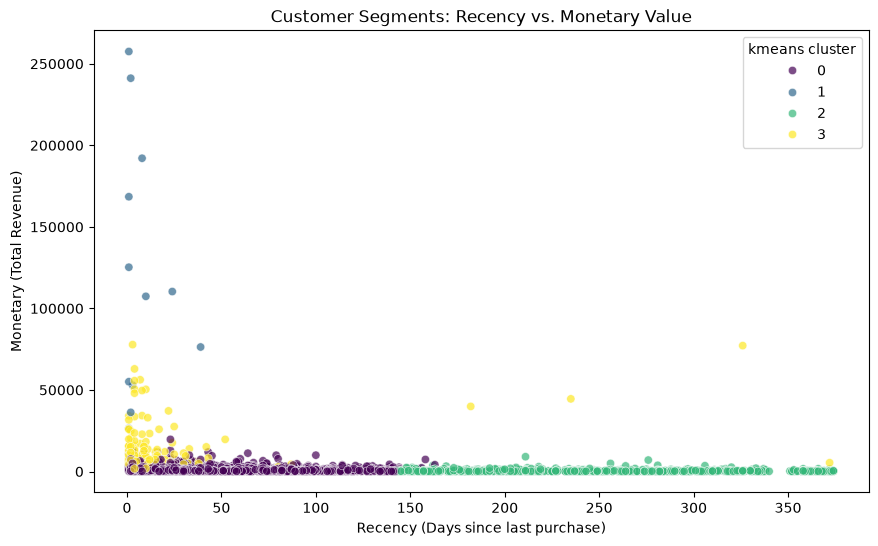

In [94]:
# Visualize the Clusters (e.g., Recency vs. Monetary)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='kmeans cluster', palette='viridis', alpha=0.7)
plt.title('Customer Segments: Recency vs. Monetary Value')
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Monetary (Total Revenue)')

In [95]:
import joblib

# Assuming 'scaler', 'kmeans_final', and 'rf_model' are your trained objects
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(kmeans, 'kmeans.pkl')
joblib.dump(rf, 'random_forest.pkl')

['random_forest.pkl']

In [96]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Re-fit the label encoders using your cleaned dataframe
le_country = LabelEncoder()
le_month = LabelEncoder()
le_day = LabelEncoder()

le_country.fit(df['Country'])
le_month.fit(df['Month'])
le_day.fit(df['Day'])

# Save them to the models directory
joblib.dump(le_country, 'le_country.pkl')
joblib.dump(le_month, 'le_month.pkl') # or '../models/le_month.pkl' depending on your notebook location
joblib.dump(le_day, 'le_day.pkl')     # or '../models/le_day.pkl'

print("Label encoders saved successfully!")

Label encoders saved successfully!


In [97]:
import joblib

# Load the saved model
rf_model = joblib.load('random_forest.pkl')

# Print the feature names the model was trained on
print("The model expects these 6 features:", rf_model.feature_names_in_)

The model expects these 6 features: ['Quantity' 'UnitPrice' 'Country' 'Month' 'Day' 'Hour']


In [98]:
import joblib
from sklearn.ensemble import RandomForestRegressor

# Assuming 'df' is your cleaned dataframe and 'Revenue' is what you are predicting
# 1. Define X with exactly 5 features (Drop 'Hour' and 'Revenue')
X = df[['Quantity', 'UnitPrice', 'Country', 'Month', 'Day']]
y = df['Revenue'] # Or whatever your target column is named

# 2. Retrain the model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X, y)

# 3. Overwrite the old 6-feature model with this new 5-feature model
joblib.dump(rf_model, 'random_forest.pkl')

print("Model successfully retrained on 5 features!")

Model successfully retrained on 5 features!


In [99]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Day',
       'Hour', 'Minute', 'Month1', 'Day1', 'Country1'],
      dtype='str')